In [289]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

dimensions de X: (100, 2)
dimensions de y: (100, 1)


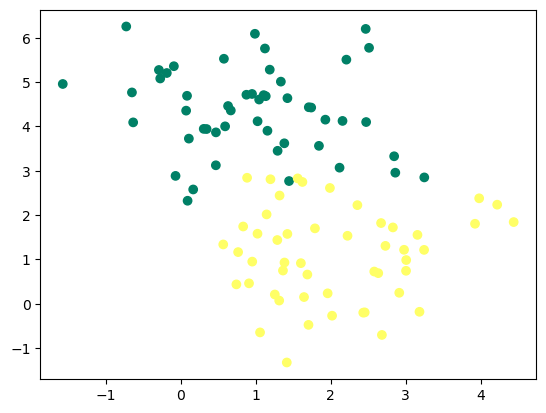

In [290]:
X , y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape(y.shape[0],1)


print('dimensions de X:', X.shape)
print('dimensions de y:',y.shape)

plt.scatter(X[:,0],X[:,1], c=y, cmap='summer')
plt.show()

In [291]:
def initialisation (X):
    W = np.random.randn(X.shape[1],1)
    b= np.random.randn(1)
    return (W,b)

In [292]:
def model (X, W, b):
    Z = X.dot(W) + b
    A=1/(1+np.exp(-Z))
    return A

In [293]:
A = model(X,W,b)
A.shape

(100, 1)

In [294]:
def log_loss(A,y):
    return -1/len(y) * np.sum((y* np.log(A))+(1-y)*(np.log(1-A)))
    

In [295]:
log_loss(A,y)

np.float64(0.7134989919587047)

In [296]:
def gradients_dc(A, X, y):
    dW = 1/len(y) * np.dot(X.T, A-y)
    db = 1/len(y) * np.sum(A-y)
    return (dW,db)

In [297]:
def update(dW, db, W, b, learning_rate):
    W = W - learning_rate*dW
    b = b - learning_rate*db
    return W,b

In [298]:
def predict(X, W, b):
    A = model(X, W, b)
    print(A)
    return A >= 0.5

In [299]:
from sklearn.metrics import accuracy_score

In [300]:
def artificial_neuron(X, y, learning_rate=0.1, n_iteration = 100):
    #initialisation de W et b
    W,b = initialisation(X)
    Loss = []
    for i in range(n_iteration):
        A = model(X, W, b)
        Loss.append (log_loss(A,y))
        dW, db = gradients_dc(A, X, y)
        W, b = update(dW, db,W, b, learning_rate)

    y_pred = predict(X, W, b)
    print(accuracy_score(y, y_pred))
    plt.plot(Loss)
    plt.show()

    return (W,b)

[[9.82530706e-01]
 [5.64506694e-01]
 [5.03559188e-03]
 [7.50306877e-02]
 [9.64970825e-01]
 [3.21620295e-01]
 [7.71715743e-02]
 [9.71756427e-01]
 [4.44457631e-02]
 [7.30964875e-01]
 [3.31662375e-02]
 [7.89246721e-01]
 [4.08522908e-02]
 [1.52841031e-02]
 [6.56339724e-01]
 [9.90872273e-01]
 [9.87068916e-01]
 [3.02061674e-02]
 [5.03637300e-01]
 [5.17699255e-01]
 [5.94258985e-02]
 [3.78502120e-02]
 [3.35568518e-01]
 [5.23395630e-03]
 [9.34897479e-01]
 [3.94626592e-02]
 [7.68653396e-01]
 [1.61096029e-02]
 [9.33345810e-02]
 [7.53213984e-01]
 [9.59892995e-01]
 [5.52073447e-02]
 [4.83938616e-01]
 [9.60867663e-01]
 [3.89191800e-01]
 [3.29142814e-01]
 [6.51523927e-01]
 [5.57907344e-01]
 [5.17132642e-01]
 [2.72973117e-01]
 [3.87347257e-02]
 [1.86280480e-01]
 [9.73638434e-04]
 [1.78668327e-01]
 [1.56796892e-01]
 [8.11797747e-01]
 [9.29485691e-01]
 [9.04729764e-01]
 [3.58938702e-03]
 [1.32510774e-02]
 [8.89258266e-01]
 [3.70251511e-01]
 [1.31849880e-01]
 [6.24783502e-02]
 [8.82344417e-01]
 [5.600343

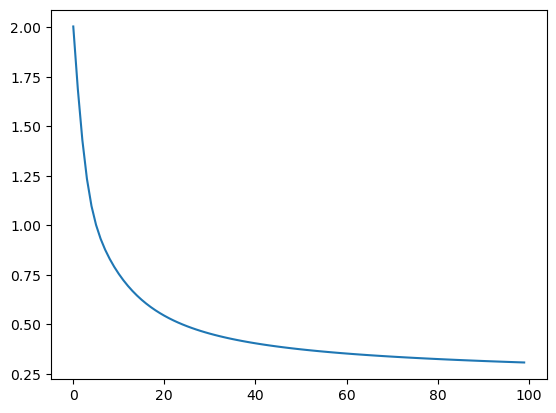

(array([[ 1.56673505],
        [-0.79848084]]),
 array([-0.79563117]))

In [301]:
artificial_neuron(X, y)

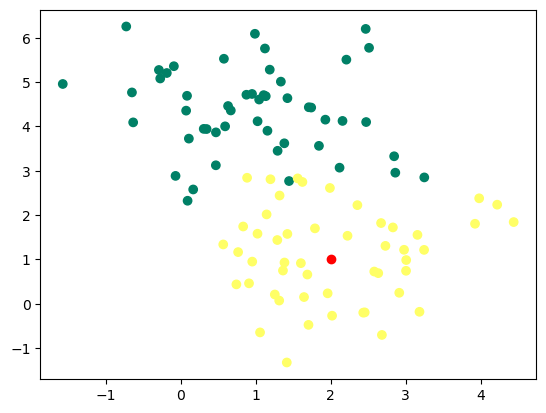

[0.86721719]


array([ True])

In [306]:
new_plant = np.array([2, 1])



plt.scatter(X[:,0], X[:,1], c=y, cmap='summer')
plt.scatter(new_plant[0], new_plant[1], c='r')
plt.show()
predict(new_plant, W, b)